In [1]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [2]:
import sys
import sklearn
import pandas
import scipy
import tensorflow

print("Python :", sys.executable)
print("sklearn:", sklearn.__version__)
print("pandas :", pandas.__version__)
print("scipy  :", scipy.__version__)
print("tf     :", tensorflow.__version__)

2026-07-10 12:29:51.272918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python : /usr/local/Caskroom/miniconda/base/envs/fakebusters-clean/bin/python
sklearn: 1.9.0
pandas : 3.0.3
scipy  : 1.17.1
tf     : 2.16.2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.bilstm import create_lstm_features, build_bilstm_model
from src.evaluator import save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_vectorizer
from src.config import MODELS_DIR, PLOT_DIR

In [4]:
# Class constants
MODEL_ID = "exp_16"
MODEL_NAME = "Bi-LSTM"
FEATURES = "Keras integer sequences with trainable embedding layer"
PREPROCESSING = "Lowercase + HTML removal + stopword removal + lemmatization"
ALGORITHM = "Bidirectional LSTM"
NOTES = "Bi-LSTM model using padded text sequences and a trainable embedding layer."

MODEL_PATH = MODELS_DIR / "bilstm_model.keras"
TOKENIZER_PATH = MODELS_DIR / "bilstm_tokenizer.pkl"

MAX_WORDS = 20000
MAX_LENGTH = 300
EMBEDDING_DIM = 100
EPOCHS = 10
BATCH_SIZE = 64

In [5]:
# Load the dataset
data = load_data()

# Extract features X and labels y
X, y = prepare_features_and_labels(data)

# Keep the original 80/20 project split
X_train_full, X_test, y_train_full, y_test = split_data(X, y)

# Create a validation set from the training portion
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (27160, 2)
Validation: (4793, 2)
Test: (7989, 2)


In [6]:
# Clean title and text and create combined_text
X_train_clean = preprocess_data(X_train)
X_val_clean = preprocess_data(X_val)
X_test_clean = preprocess_data(X_test)

In [7]:
# Learn the tokenizer only from the training data
X_train_padded, X_test_padded, tokenizer = create_lstm_features(
    X_train_clean,
    X_test_clean,
    max_words=MAX_WORDS,
    max_length=MAX_LENGTH
)

# Validation data must use the same fitted tokenizer
val_sequences = tokenizer.texts_to_sequences(
    X_val_clean["combined_text"]
)

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_val_padded = pad_sequences(
    val_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Train shape:", X_train_padded.shape)
print("Validation shape:", X_val_padded.shape)
print("Test shape:", X_test_padded.shape)

Train shape: (27160, 300)
Validation shape: (4793, 300)
Test shape: (7989, 300)


In [8]:
# Build the model
model = build_bilstm_model(
    max_words=MAX_WORDS,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_LENGTH
)

model.summary()

/usr/local/Caskroom/miniconda/base/envs/fakebusters-clean/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

Epoch 1/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 98s 219ms/step - accuracy: 0.9046 - loss: 0.1924 - val_accuracy: 0.9983 - val_loss: 0.0056
Epoch 2/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 93s 219ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9985 - val_loss: 0.0068
Epoch 3/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 103s 243ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9981 - val_loss: 0.0060


In [10]:
# Predict train and test probabilities
train_probabilities = model.predict(X_train_padded).ravel()
test_probabilities = model.predict(X_test_padded).ravel()

# Convert probabilities to class labels
train_predictions = (train_probabilities >= 0.5).astype(int)
predictions = (test_probabilities >= 0.5).astype(int)

train_accuracy = accuracy_score(y_train, train_predictions)

metrics = {
    "test_accuracy": accuracy_score(y_test, predictions),
    "precision": precision_score(y_test, predictions, zero_division=0),
    "recall": recall_score(y_test, predictions, zero_division=0),
    "f1_score": f1_score(y_test, predictions, zero_division=0)
}

metrics

849/849 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step


{'test_accuracy': 0.9991237952184253,
 'precision': 0.9990002499375156,
 'recall': 0.99925,
 'f1_score': 0.9991251093613298}

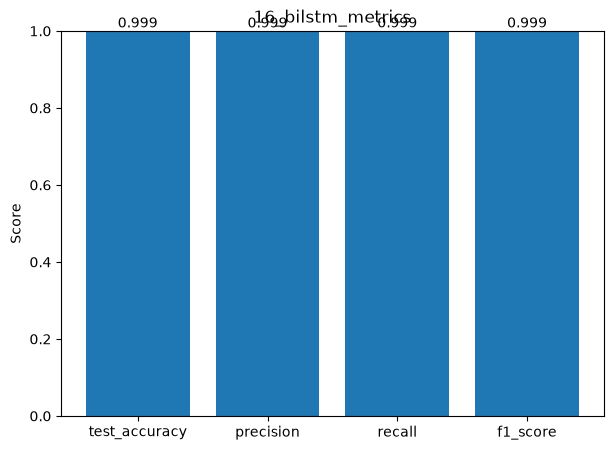

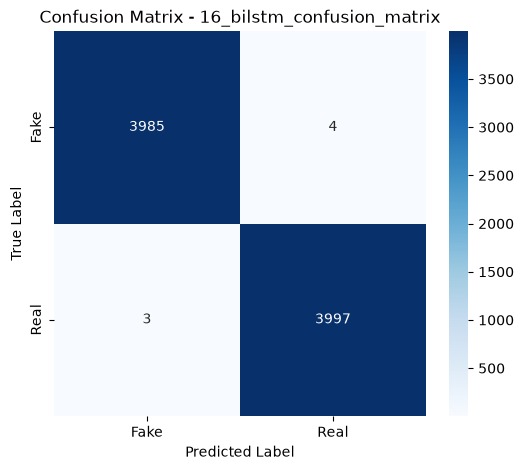

In [11]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "16_bilstm_metrics"
)

# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "16_bilstm_confusion_matrix"
)

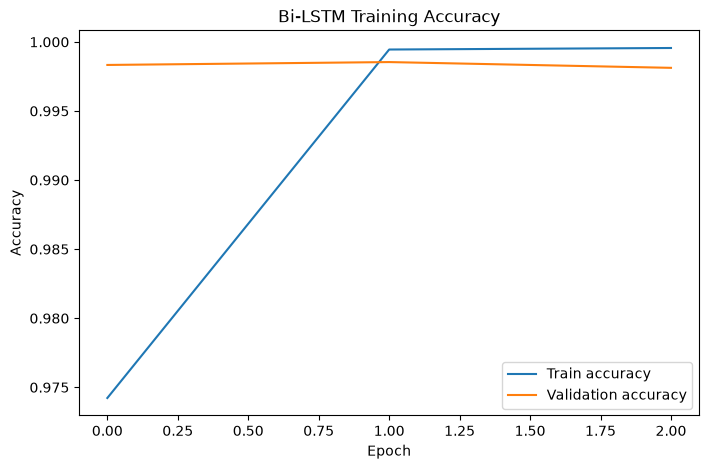

In [12]:
# Save training history plot
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Bi-LSTM Training Accuracy")
plt.legend()

training_plot_path = PLOT_DIR / "16_bilstm_training_accuracy.png"
plt.savefig(training_plot_path, bbox_inches="tight")
plt.show()

In [13]:
# Save model and fitted tokenizer
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

model.save(MODEL_PATH)

tokenizer_path = save_vectorizer(
    tokenizer,
    "bilstm_tokenizer.pkl"
)

print(f"Model saved to: {MODEL_PATH}")
print(f"Tokenizer saved to: {tokenizer_path}")

Vectorizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bilstm_tokenizer.pkl
Model saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bilstm_model.keras
Tokenizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bilstm_tokenizer.pkl


In [14]:
# Save experiment result
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": FEATURES,
    "preprocessing": PREPROCESSING,
    "algorithm": ALGORITHM,
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": NOTES,
    "model_path": MODEL_PATH,
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
19,exp_11,Random Forest + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.997497,0.997749,0.99725,0.997499,Random Forest model using TF-IDF unigram and b...,/Users/karima/Ironhack-challenges/fake-news-nl...
20,exp_12,SVM + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Linear SVM,0.999437,0.994367,0.994499,0.99425,0.994374,Linear SVM model using TF-IDF unigram and bigr...,/Users/karima/Ironhack-challenges/fake-news-nl...
21,exp_07,Random Forest + TF-IDF,TF-IDF,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.998248,0.997752,0.99875,0.998251,Random Forest model using TF-IDF features.,/Users/karima/Ironhack-challenges/fake-news-nl...
22,exp_07,Random Forest + TF-IDF,TF-IDF,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.997997,0.998249,0.99775,0.997999,Random Forest model using TF-IDF features.,/Users/karima/Ironhack-challenges/fake-news-nl...
23,exp_16,Bi-LSTM,Keras integer sequences with trainable embeddi...,Lowercase + HTML removal + stopword removal + ...,Bidirectional LSTM,0.999669,0.999124,0.999000,0.99925,0.999125,Bi-LSTM model using padded text sequences and ...,/Users/karima/Ironhack-challenges/fake-news-nl...
